# Al respecto del Google Colab (.ipynb)

# Markdown (Titulo)

## Subtítulo

* Punto de observación
* Punto de observación II

1. Pto 1
1. Pto 3



In [1]:
print("Esto es un comando basico en Python")

Esto es un comando basico en Python


# Clase:

# Cubo de datos geoespaciales




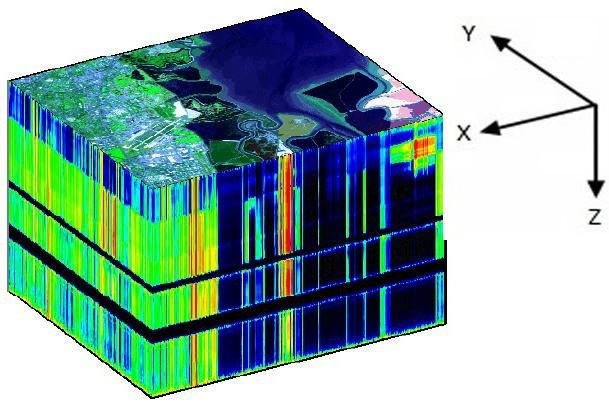

## Acceso a los datos

Para poder acceder a los datos usados en este *GoogleColab*, ustedes deberán acceder a [esta carpeta](https://drive.google.com/drive/folders/1fGAxtJ3QXI2i39pjSfW8rXdSn-I9iCQk?usp=sharing) y hacer una copia al drive de ustedes. Es importante que puedan acordarse dónde la han guardado para acceder a los datos más adelante.

## Montando Google Drive

Vamos a conectar al drive para poder acceder a la carpeta de datos que fue compartida en las primeras clases.
Por las dudas:
[Se trata de esta carpeta](https://drive.google.com/drive/folders/1fGAxtJ3QXI2i39pjSfW8rXdSn-I9iCQk?usp=sharing).  Se espera que ustedes hagan un acceso directo a ella en el drive de ustedes, si no lo hicieron antes.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Contextualización

La mayoría de los datos espaciales no poseen **solamente** como atributos su ubicación en el espacio (Latitude y Longitud), si no que, también, poseen el atributo temporal.

O sea, debería nos ayudar a entender el **donde y cuando** algo ha ocurrido.

Es por eso que una de las tareas más comunes al analizar datos espaciales está en manipularlo también en función del tiempo. Solemos hacer eso siempre, pero sin darnos cuenta. Por ejemplo, al elegir el año de la capa de cobertura del suelo de MapBiomas. O cuando manipulamos datos de censo forestal de una determinada época.

**De alguna manera, estamos trabajando con la variable temporal, aunque eso sea hecho de manera estatica, no dinâmica.**

Por ejemplo, cuando buscamos una imagen de satelite, tenemos que definir una (o un rango de) fecha(s), ya que, puede ser que estemos buscamos imagenes anteriores o posteriores a un determinado hecho.

O cuando analizarmos un conjunto de datos de precios de departamentos alquilados por _AirBNB_, tendremos o deberíamos tener el atributo temporal llevado en consideración. Al final, la cercanía al año nuevo hace con que los preciso de alquiler de departamentos en Rio de Janeiro, por ejemplo, hará con que los precios suban.

> **Lo que no nos damos cuenta es que estamos siempre, mismo sin querer, trabajando con el abordaje "espacio-temporal".**

Y, claro, como siempre, para dicho abordaje, existe una estructura de datos específica: **los cubos de datos**.

Vamos a trabajar con dicha estructura de dato para entender su potencialidad e importancia.

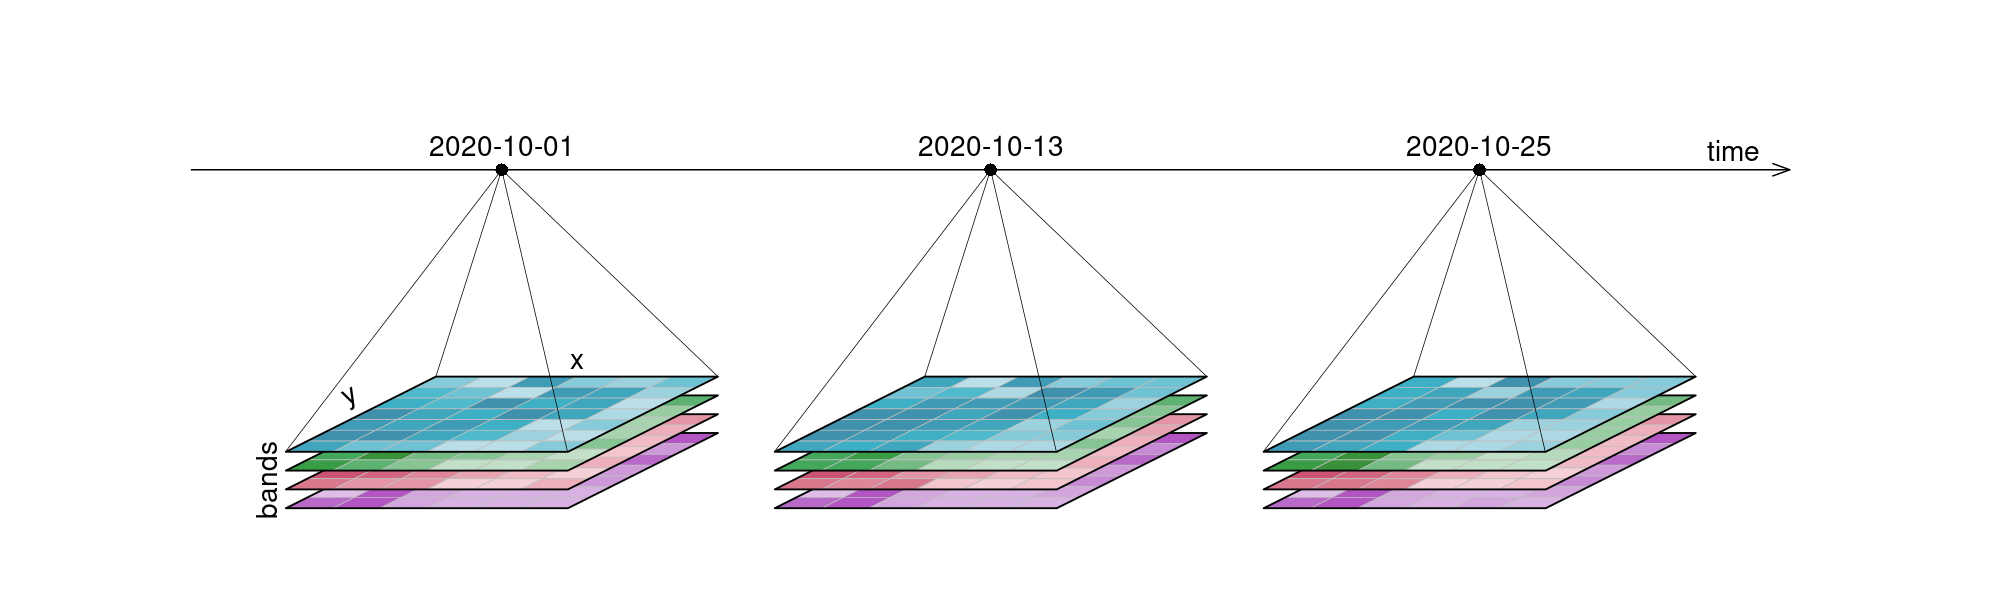

<figure>
    <img src="https://raw.githubusercontent.com/r-spatial/stars/main/images/cube2.png" width=60%
         alt="Ilustración de las imágenes de satélites organizadas en la estrcutura de cubo de datos.">
    <figcaption>Ilustración de las imágenes de satélites organizadas en la estrcutura de cubo de datos.</figcaption>
</figure>

<figure>
    <img src="https://raw.githubusercontent.com/r-spatial/stars/main/images/cube1.png" width=60%
         alt="Ilustración de un cubo de datos matricial.">
    <figcaption>Ilustración de un cubo de datos matricial.</figcaption>
</figure>

<figure>
    <img src="https://raw.githubusercontent.com/r-spatial/stars/main/images/cube3.png" width=70%
         alt="Ilustración de un cubo de datos vectoriales.">
    <figcaption>Ilustración de un cubo de datos vectoriales.</figcaption>
</figure>

# Organizando ambiente de trabajo

## Instalando modulos

* [xarray](https://docs.xarray.dev/en/stable/index.html)
* [xvec](https://xvec.readthedocs.io)

In [3]:
!pip install rioxarray --quiet
!pip install xvec --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.6/784.6 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 5.3 MB/s eta 0:00:00


## Importando modulos

In [4]:
import xarray
import xvec
import geopandas as gpd
from google.colab import drive
from datetime import datetime

## Carga del cubo de datos

Para cargar el cubo de datos a nuestro proyecto, vemos a ocupar el método `xarray.open_dataset()`:
> No se olviden de adaptar la _ruta_ a la carpeta compartida!

In [5]:
ds = xarray.open_dataset(
    "/content/drive/MyDrive/UNaM/FCF/TUSIGyT/Primer cuatrimestre/GAAT - Geomática_Analisis_Territorial/2024/Datos/2022_pm2p5.nc"
    )

In [6]:
ds

<xarray.Dataset> Size: 98MB
Dimensions:    (time: 2920, latitude: 84, longitude: 50)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Data variables:
    pm2p5      (time, latitude, longitude) float64 98MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-19 16:53:09 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

# Entendiendo el dato `xarray`

Este modelo de datos `xarray` está estructurado de manera similar al formato de archivo `netCDF`. [`NetCDF`](https://en.wikipedia.org/wiki/NetCDF) es muy popular en las geociencias, y existen bibliotecas para leer y escribir `netCDF` en muchos lenguajes de programación, incluido Python.

### `xarray.Dataset`

* Es una colección de objetos `DataArray` **con dimensiones alineadas y compartidas**.  
  Podría ser comparada a una _**base de datos**_ (pero matricial - _array_ multidimensional) y en memoria.

  Es un contenedor tipo dict de objetos `DataArray` alineados a lo largo de cualquier número de **dimensiones compartidas**, y sirve a un propósito similar en `xarray` al de [`pandas.DataFrame`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html).

#### pandas.DataFrame

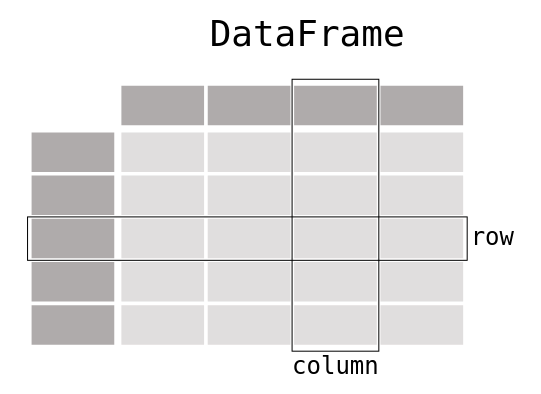

Los conjuntos de datos `xarray` (`xarray.Dataset`) tienen variables (_variables_), dimensiones (_dimensions_), coordenadas (_coordinates_) y atributos (_attributes_).

In [7]:
print("Variables: ", ds.data_vars)
print("Dimensiones: ", ds.dims)
print("Coordenadas: ", ds.coords)

Variables:  Data variables:
    pm2p5    (time, latitude, longitude) float64 98MB ...
Dimensiones:  FrozenMappingWarningOnValuesAccess({'time': 2920, 'latitude': 84, 'longitude': 50})
Coordenadas:  Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97


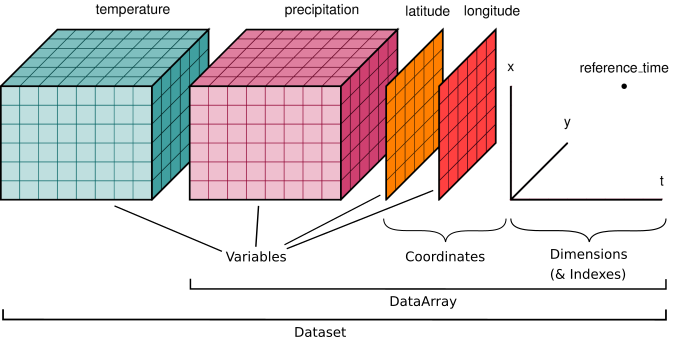

### Accediendo a una variable

Al acceder a una variable, empezamos a trabajar con un `xarray.DataArray`.

In [8]:
ds.pm2p5

<xarray.DataArray 'pm2p5' (time: 2920, latitude: 84, longitude: 50)> Size: 98MB
[12264000 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Attributes:
    units:          kg m**-3
    long_name:      Particulate matter d <= 2.5 um
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

### DataArray

* `DataArray` es la implementación de una matriz (_array_) **multidimensional** (N-dimensional) **etiquetada** o con nombre.  
  En resúmen, un `DataArray` es una matriz `array` con **metadatos como nombres de dimensiones, coordenadas y atributos**.  
  Es también una generalización N-D de [pandas.Series](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.html).

#### pandas.Series

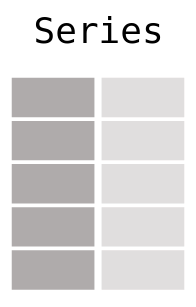

## Entendiendo cada elemento (variable, atributos, dimensiones y coordenadas)

* **`Variable`**  
Una variable es lo que identifica **que está mapeado**: Temperatura, precipitación, polución, sensores de imágenes de satélites (sus bandas), etc.  
Toda variable posee **dimensiones**, **datos** y **atributos** que describen un único conjunto de datos.  
La principal **diferencia funcional entre variables y arrays numpy es que las operaciones numéricas sobre variables son implementadas por el nombre de dimensión**.

In [9]:
ds.pm2p5

<xarray.DataArray 'pm2p5' (time: 2920, latitude: 84, longitude: 50)> Size: 98MB
[12264000 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Attributes:
    units:          kg m**-3
    long_name:      Particulate matter d <= 2.5 um
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

* **Atributos**  
Se trata de informaciones al respecto del conjunto de la variable.  
Se trata de un diccionário que puede almacenar _cualquier información_.

Ejemplo:

* Una opción útil es establecer data.attrs['long_name'] y data.attrs['units'] ya que xarray los utilizará, si están presentes, para etiquetar automáticamente tus gráficos.

Estos nombres fueron elegidos siguiendo las Convenciones de Metadatos de _NetCDF_ Climate and Forecast (CF). `attrs` es sólo un diccionario de Python, por lo que puede asignar lo que desee.

**Vamos a ver qué atributos la variabel `pm2p5` posee**:

In [10]:
ds.pm2p5.attrs

{'units': 'kg m**-3',
 'long_name': 'Particulate matter d <= 2.5 um',
 'standard_name': 'mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air'}

Podemos agregar atributos que nos parezca importante:

In [11]:
print("Nombre largo antiguo: ", ds.pm2p5.attrs["long_name"])
ds.pm2p5.attrs["long_name"] = 'Material particulado fino, 2.5 micrometros'
print("Nombre largo actualizado: ", ds.pm2p5.attrs["long_name"])
ds.pm2p5.attrs["Fecha_clase"] = '06/11/2025'
print("Nuevo atributo creado: ", ds.pm2p5.attrs["Fecha_clase"])

Nombre largo antiguo:  Particulate matter d <= 2.5 um
Nombre largo actualizado:  Material particulado fino, 2.5 micrometros
Nuevo atributo creado:  06/11/2025


* **`Dimension`**  
Creo que sea autoexplicativo, no?  
Pero lo interesante es saber que cada eje de dimensión tiene un nombre, por ejemplo, en nuestro conjunto de dato, la dimensión `longitude`.  
En `xarray`, las dimensiones de un objeto `DataArray` son sus ejes de dimensión con nombre. Para conocer el nombre de las dimensiones, basta ejecutar `da.dims` (`da` = `DataArray`).  
Si se crea un array sin especificar los nombres de las dimensiones, se le asignarán, por defecto, `dim_0`, `dim_1`, y así sucesivamente.

In [12]:
ds.pm2p5.dims

('time', 'latitude', 'longitude')

<figure>
    <img src="https://raw.githubusercontent.com/r-spatial/stars/main/images/cube1.png" width=60%
         alt="Ilustración de un cubo de datos matricial.">
    <figcaption>Ilustración de un cubo de datos matricial.</figcaption>
</figure>

* **`Coordinate`**  
Los valores de la matriz de coordenadas pueden considerarse como etiquetas a lo largo de una dimensión.  
Una coordenada llamada x puede recuperarse de `arr.coords[x]`.  
**Un DataArray puede tener más coordenadas que dimensiones porque una sola dimensión puede ser etiquetada por múltiples matrices de coordenadas. Sin embargo, sólo se puede asignar una matriz de coordenadas como matriz de coordenadas de una dimensión concreta.**

In [14]:
ds.pm2p5.coords['latitude']

<xarray.DataArray 'latitude' (latitude: 84)> Size: 336B
array([-21.863, -22.263, -22.663, -23.063, -23.463, -23.863, -24.263, -24.663,
       -25.063, -25.463, -25.863, -26.263, -26.663, -27.063, -27.463, -27.863,
       -28.263, -28.663, -29.063, -29.463, -29.863, -30.263, -30.663, -31.063,
       -31.463, -31.863, -32.263, -32.663, -33.063, -33.463, -33.863, -34.263,
       -34.663, -35.063, -35.463, -35.863, -36.263, -36.663, -37.063, -37.463,
       -37.863, -38.263, -38.663, -39.063, -39.463, -39.863, -40.263, -40.663,
       -41.063, -41.463, -41.863, -42.263, -42.663, -43.063, -43.463, -43.863,
       -44.263, -44.663, -45.063, -45.463, -45.863, -46.263, -46.663, -47.063,
       -47.463, -47.863, -48.263, -48.663, -49.063, -49.463, -49.863, -50.263,
       -50.663, -51.063, -51.463, -51.863, -52.263, -52.663, -53.063, -53.463,
       -53.863, -54.263, -54.663, -55.064], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
Attributes:
    units:      degrees_north
    long_name:  latitude

In [25]:
ds.pm2p5

<xarray.DataArray 'pm2p5' (time: 2920, latitude: 84, longitude: 50)> Size: 98MB
array([[[12.5335674 , 11.33082509, 10.53565658, ...,  7.2670745 ,
          6.9913628 ,  8.07822629],
        [16.76514249, 15.87007845, 12.10601448, ...,  7.87443938,
          8.24205497,  9.26098949],
        [17.61225668, 15.90604084, 13.35670665, ...,  7.1392082 ,
          7.9703391 ,  8.19810093],
        ...,
        [11.69444485,  2.86367907,  0.83380168, ..., 26.45101411,
         25.63986232, 24.94858518],
        [18.21962156,  6.81155083,  3.46704813, ..., 25.86362833,
         25.58791664, 25.37214227],
        [20.47326496, 16.03390714, 12.40170528, ..., 24.58896123,
         25.05247654, 25.18833447]],

       [[14.85913558, 15.86208681, 13.90813003, ...,  9.88034184,
          8.74952432,  9.50073878],
        [14.1798459 , 15.38658403, 16.47344752, ..., 10.29191146,
         10.49170255, 11.76237382],
        [15.97396981, 15.63432497, 15.27070521, ...,  9.34490174,
         10.61956884, 11.28687105],
...
        [13.31492023,  7.06195632,  5.8484677 , ..., 19.71386774,
         19.85072736, 20.44986835],
        [14.0205076 ,  9.41898309, 10.02724806, ..., 19.85376868,
         20.28563681, 20.6262652 ],
        [17.96510594, 21.7028942 , 25.24299633, ..., 20.94256298,
         20.96385226, 21.05205068]],

       [[ 9.55584271, 10.11240516, 11.3167698 , ...,  5.72073206,
          4.99689674,  4.71709486],
        [ 9.37032189, 10.02116541, 11.41105087, ...,  5.89104625,
          5.52000462,  5.23716141],
        [ 8.5400402 ,  9.25475155, 10.49561209, ...,  6.25904656,
          6.11610429,  5.62645099],
        ...,
        [14.91161579,  9.28212347,  7.23227052, ..., 20.25826489,
         20.98818285, 22.48755601],
        [15.84226119,  9.7139916 ,  8.10513075, ..., 20.76312481,
         21.48696013, 22.35982037],
        [15.95174889, 15.35869054, 15.87571577, ..., 21.176745  ,
         21.46262953, 21.66335697]]])
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Attributes:
    units:          µm
    long_name:      Particulate matter d <= 2.5 µm
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

## Convertiendo el valor de PM<2.5

**Los datos de Particulado fino están en kg**. Por eso vamos a corvertirlos a microgramo, para identificar cuando y donde hubo exposición al particulado fino acorde a las nuevas [diretrices de la Organización Mundial de la Salud](https://www.who.int/es/news/item/22-09-2021-new-who-global-air-quality-guidelines-aim-to-save-millions-of-lives-from-air-pollution):


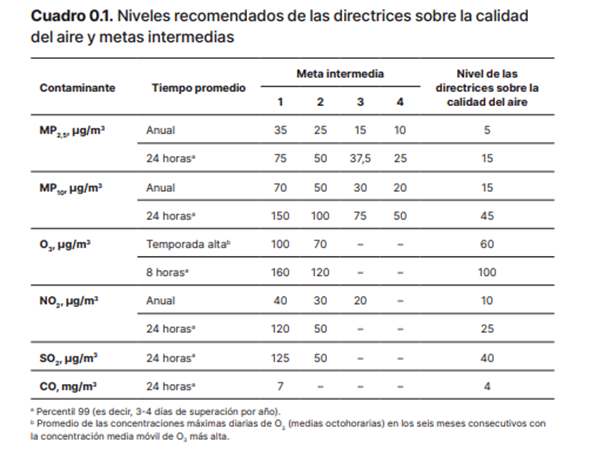

Para convertir los valores basta multiplicarlos por 100000000, o `1e9`:

In [17]:
ds['pm2p5'] = ds.pm2p5 * 1e9

Vamos confirmar el resultado

In [18]:
ds.pm2p5

<xarray.DataArray 'pm2p5' (time: 2920, latitude: 84, longitude: 50)> Size: 98MB
array([[[12.5335674 , 11.33082509, 10.53565658, ...,  7.2670745 ,
          6.9913628 ,  8.07822629],
        [16.76514249, 15.87007845, 12.10601448, ...,  7.87443938,
          8.24205497,  9.26098949],
        [17.61225668, 15.90604084, 13.35670665, ...,  7.1392082 ,
          7.9703391 ,  8.19810093],
        ...,
        [11.69444485,  2.86367907,  0.83380168, ..., 26.45101411,
         25.63986232, 24.94858518],
        [18.21962156,  6.81155083,  3.46704813, ..., 25.86362833,
         25.58791664, 25.37214227],
        [20.47326496, 16.03390714, 12.40170528, ..., 24.58896123,
         25.05247654, 25.18833447]],

       [[14.85913558, 15.86208681, 13.90813003, ...,  9.88034184,
          8.74952432,  9.50073878],
        [14.1798459 , 15.38658403, 16.47344752, ..., 10.29191146,
         10.49170255, 11.76237382],
        [15.97396981, 15.63432497, 15.27070521, ...,  9.34490174,
         10.61956884, 11.28687105],
...
        [13.31492023,  7.06195632,  5.8484677 , ..., 19.71386774,
         19.85072736, 20.44986835],
        [14.0205076 ,  9.41898309, 10.02724806, ..., 19.85376868,
         20.28563681, 20.6262652 ],
        [17.96510594, 21.7028942 , 25.24299633, ..., 20.94256298,
         20.96385226, 21.05205068]],

       [[ 9.55584271, 10.11240516, 11.3167698 , ...,  5.72073206,
          4.99689674,  4.71709486],
        [ 9.37032189, 10.02116541, 11.41105087, ...,  5.89104625,
          5.52000462,  5.23716141],
        [ 8.5400402 ,  9.25475155, 10.49561209, ...,  6.25904656,
          6.11610429,  5.62645099],
        ...,
        [14.91161579,  9.28212347,  7.23227052, ..., 20.25826489,
         20.98818285, 22.48755601],
        [15.84226119,  9.7139916 ,  8.10513075, ..., 20.76312481,
         21.48696013, 22.35982037],
        [15.95174889, 15.35869054, 15.87571577, ..., 21.176745  ,
         21.46262953, 21.66335697]]])
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97

Cómo cambiamos el valor, debemos cambiar el metadato:  
`ds.pm2p5.attr` asignandole un dicionario con lo que queremos:
```
{'units': 'µm',
 'long_name': 'Particulate matter d <= 2.5 µm',
 'standard_name': 'mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air'}
 ```

In [19]:
ds.pm2p5.attrs = {'units': 'µm',
 'long_name': 'Particulate matter d <= 2.5 µm',
 'standard_name': 'mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air'}

In [21]:
ds.pm2p5

<xarray.DataArray 'pm2p5' (time: 2920, latitude: 84, longitude: 50)> Size: 98MB
array([[[12.5335674 , 11.33082509, 10.53565658, ...,  7.2670745 ,
          6.9913628 ,  8.07822629],
        [16.76514249, 15.87007845, 12.10601448, ...,  7.87443938,
          8.24205497,  9.26098949],
        [17.61225668, 15.90604084, 13.35670665, ...,  7.1392082 ,
          7.9703391 ,  8.19810093],
        ...,
        [11.69444485,  2.86367907,  0.83380168, ..., 26.45101411,
         25.63986232, 24.94858518],
        [18.21962156,  6.81155083,  3.46704813, ..., 25.86362833,
         25.58791664, 25.37214227],
        [20.47326496, 16.03390714, 12.40170528, ..., 24.58896123,
         25.05247654, 25.18833447]],

       [[14.85913558, 15.86208681, 13.90813003, ...,  9.88034184,
          8.74952432,  9.50073878],
        [14.1798459 , 15.38658403, 16.47344752, ..., 10.29191146,
         10.49170255, 11.76237382],
        [15.97396981, 15.63432497, 15.27070521, ...,  9.34490174,
         10.61956884, 11.28687105],
...
        [13.31492023,  7.06195632,  5.8484677 , ..., 19.71386774,
         19.85072736, 20.44986835],
        [14.0205076 ,  9.41898309, 10.02724806, ..., 19.85376868,
         20.28563681, 20.6262652 ],
        [17.96510594, 21.7028942 , 25.24299633, ..., 20.94256298,
         20.96385226, 21.05205068]],

       [[ 9.55584271, 10.11240516, 11.3167698 , ...,  5.72073206,
          4.99689674,  4.71709486],
        [ 9.37032189, 10.02116541, 11.41105087, ...,  5.89104625,
          5.52000462,  5.23716141],
        [ 8.5400402 ,  9.25475155, 10.49561209, ...,  6.25904656,
          6.11610429,  5.62645099],
        ...,
        [14.91161579,  9.28212347,  7.23227052, ..., 20.25826489,
         20.98818285, 22.48755601],
        [15.84226119,  9.7139916 ,  8.10513075, ..., 20.76312481,
         21.48696013, 22.35982037],
        [15.95174889, 15.35869054, 15.87571577, ..., 21.176745  ,
         21.46262953, 21.66335697]]])
Coordinates:
  * time       (time) datetime64[ns] 23kB 2022-01-01T06:00:00 ... 2023-01-01T...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Attributes:
    units:          µm
    long_name:      Particulate matter d <= 2.5 µm
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

# Manipulación

### `isel()` or "integer select":  

Podemos manipular el cubo de datos selectionando datos por el nombre de la dimensión e informando por un número entero (**por su indice**) qué elemento estamos queremos acceder.;

> Ejemplo:  
> Quiero acceder a la concentración de particulado fino del primer elemento **en la dimensión de tiempo** de nuestro cubo de datos: `ds.isel(time=0).variable`

In [26]:
ds.isel(time=0).pm2p5

<xarray.DataArray 'pm2p5' (latitude: 84, longitude: 50)> Size: 34kB
array([[12.5335674 , 11.33082509, 10.53565658, ...,  7.2670745 ,
         6.9913628 ,  8.07822629],
       [16.76514249, 15.87007845, 12.10601448, ...,  7.87443938,
         8.24205497,  9.26098949],
       [17.61225668, 15.90604084, 13.35670665, ...,  7.1392082 ,
         7.9703391 ,  8.19810093],
       ...,
       [11.69444485,  2.86367907,  0.83380168, ..., 26.45101411,
        25.63986232, 24.94858518],
       [18.21962156,  6.81155083,  3.46704813, ..., 25.86362833,
        25.58791664, 25.37214227],
       [20.47326496, 16.03390714, 12.40170528, ..., 24.58896123,
        25.05247654, 25.18833447]])
Coordinates:
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
    time       datetime64[ns] 8B 2022-01-01T06:00:00
Attributes:
    units:          µm
    long_name:      Particulate matter d <= 2.5 µm
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

Podemos visualizar la concentración añadiendo el método `plot()` al final:

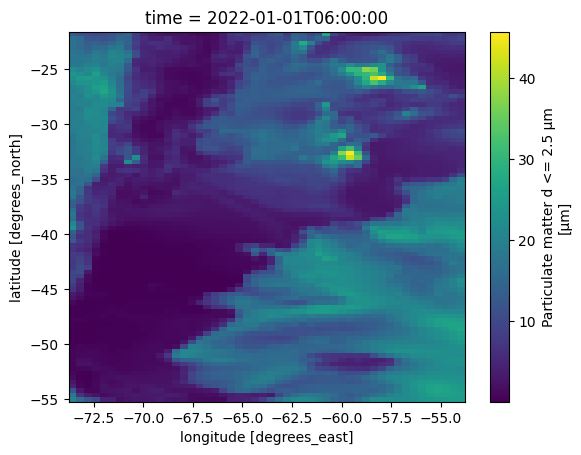

In [27]:
ds.isel(time=0).pm2p5.plot()

Interesante, no?  

**Qué pasa si seleciono no la dimención del tiempo si no que una dimención espacial?**

Al hacerlo, por ejemplo, selecionando el primer elemento de longitud, tendremos un grafico que nos va a permitir identificar la variación del particulado en la dimensión de latitud:  


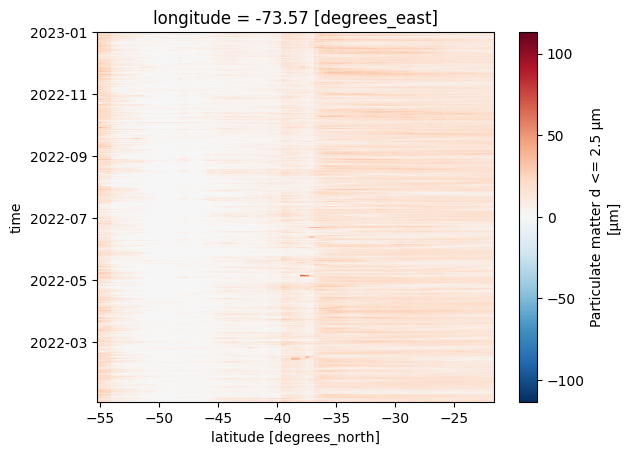

In [28]:
ds.isel(longitude=0).pm2p5.plot()

[Este sistema es interesante como ejemplo de visualización](https://www.lexcube.org/?!esdc-3.0.2/air_temperature_2m/0-1976/196-668/298-770).

**Pero y se necesitamos conocer la concentración de particulado no para una fecha, si no que, para una secuencia de fechas?**

Se peude hacer eso usando el `slice`, el cual debería recibir el indice inicial y final del `array` a ser presentado.

> Ejemplo:
> Quiero representar graficamente los cinco primeros registros en la dimensión temporal de la variable de concentración de particulado fino:
```
ds.isel(time=
        slice(0, 5)
        ).pm2p5
```


In [32]:
ds.isel(
    time =
    slice(0, 5)
).pm2p5

<xarray.DataArray 'pm2p5' (time: 5, latitude: 84, longitude: 50)> Size: 168kB
array([[[12.5335674 , 11.33082509, 10.53565658, ...,  7.2670745 ,
          6.9913628 ,  8.07822629],
        [16.76514249, 15.87007845, 12.10601448, ...,  7.87443938,
          8.24205497,  9.26098949],
        [17.61225668, 15.90604084, 13.35670665, ...,  7.1392082 ,
          7.9703391 ,  8.19810093],
        ...,
        [11.69444485,  2.86367907,  0.83380168, ..., 26.45101411,
         25.63986232, 24.94858518],
        [18.21962156,  6.81155083,  3.46704813, ..., 25.86362833,
         25.58791664, 25.37214227],
        [20.47326496, 16.03390714, 12.40170528, ..., 24.58896123,
         25.05247654, 25.18833447]],

       [[14.85913558, 15.86208681, 13.90813003, ...,  9.88034184,
          8.74952432,  9.50073878],
        [14.1798459 , 15.38658403, 16.47344752, ..., 10.29191146,
         10.49170255, 11.76237382],
        [15.97396981, 15.63432497, 15.27070521, ...,  9.34490174,
         10.61956884, 11.28687105],
...
        [16.62798326,  6.84186832,  2.81339121, ..., 21.20792243,
         21.6939568 , 22.36692745],
        [20.63776674,  9.65525953,  5.30899072, ..., 22.32954019,
         23.14271307, 24.02131364],
        [22.79688092, 20.07695786, 16.02044031, ..., 22.75014685,
         23.37638343, 24.10543498]],

       [[15.00163751, 14.3567073 , 14.17911782, ...,  2.33670366,
          1.93479063,  1.916097  ],
        [16.31019156, 15.77742312, 14.62776492, ...,  2.40213136,
          2.22454189,  2.06564604],
        [16.95512177, 16.10456164, 15.87089127, ...,  2.20584826,
          2.19650144,  2.27127596],
        ...,
        [12.23498037, 10.03847893,  7.37463676, ..., 17.81502872,
         18.56277389, 19.45072128],
        [10.77687729,  9.73003405,  9.56179138, ..., 18.45061211,
         19.49745535, 20.81535622],
        [10.94511995, 14.27258597, 17.40376887, ..., 19.60961713,
         20.69384763, 21.74069087]]])
Coordinates:
  * time       (time) datetime64[ns] 40B 2022-01-01T06:00:00 ... 2022-01-01T1...
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Attributes:
    units:          µm
    long_name:      Particulate matter d <= 2.5 µm
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

**Atención:** Para representación grafica tendremos que informar qué columna deverá ser usada en el plot. En ese caso, queremos representar la dimensión `time`.

```
ds.isel(time=
        slice(0, 5)
        ).pm2p5.plot(col='time')
```

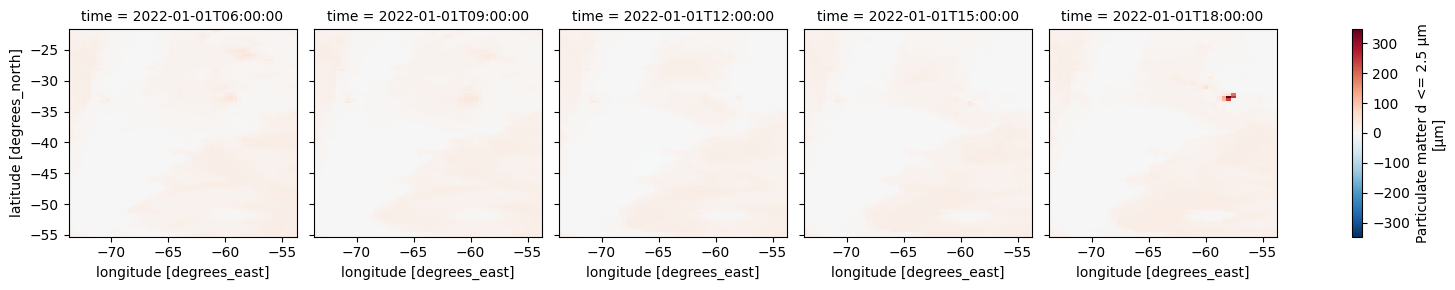

In [34]:
ds.isel(time=slice(0,5)).pm2p5.plot(col='time')

# Aciendo el uso avanzado
Hasta acá el uso de cubo de datos no tienen mucho sentido, ya que seguimos usando el `index` para selecionar los datos.
Selecionar los primeros o ultimos datos se hace de manera bastante facil.
Pero, ¿como selecionar la fecha `25/06/2023`, por ejemlpo?

¿En qué indice dicha fecha estaría?

Este sería la gran ventaja de usar el cubo de datos en python: poder usar un lenguaje más "alto nível".

Veamos como hacerlo

### `sel()` o select

Simplemente no tiene sentido, al tener un dato con dimensiones espaciales y temporales, trabajar con ellos a partir de sus índices, ya que:
1. Necesitamos saber cuando una cosa ocurrió. Y hasta identificar cual es el indice que represente dicha fecha, ya perdimos tiempo.  
1. El cubo de dato almacena el dato de tiempo (`fecha y hora`) en un formato más inteligente. **No en el formato de texto.**

Para dicho tipo de uso tenemos el método `sel()`. Con ese método podemos informar la dimención y el valor deseado.

> Ejemplo:
> Hubo incendio en Misiones en el día 31/01/2022 (`2022-01-31`). Necitamos acceder a la concentración de particulado fino para dicha fecha.

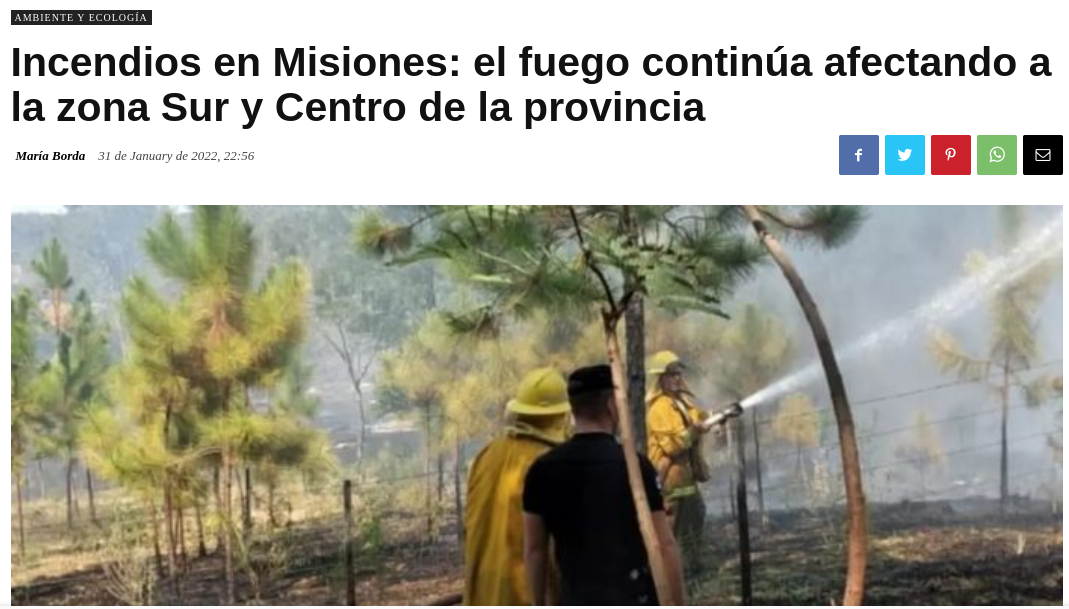

In [35]:
ds.sel(time='2022-01-31')

<xarray.Dataset> Size: 269kB
Dimensions:    (time: 8, latitude: 84, longitude: 50)
Coordinates:
  * time       (time) datetime64[ns] 64B 2022-01-31 ... 2022-01-31T21:00:00
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Data variables:
    pm2p5      (time, latitude, longitude) float64 269kB 9.683 11.52 ... 12.21
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-19 16:53:09 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

Para hacer el plot tenemos que hacer `ds.sel(...).variable.plot(col='...')`

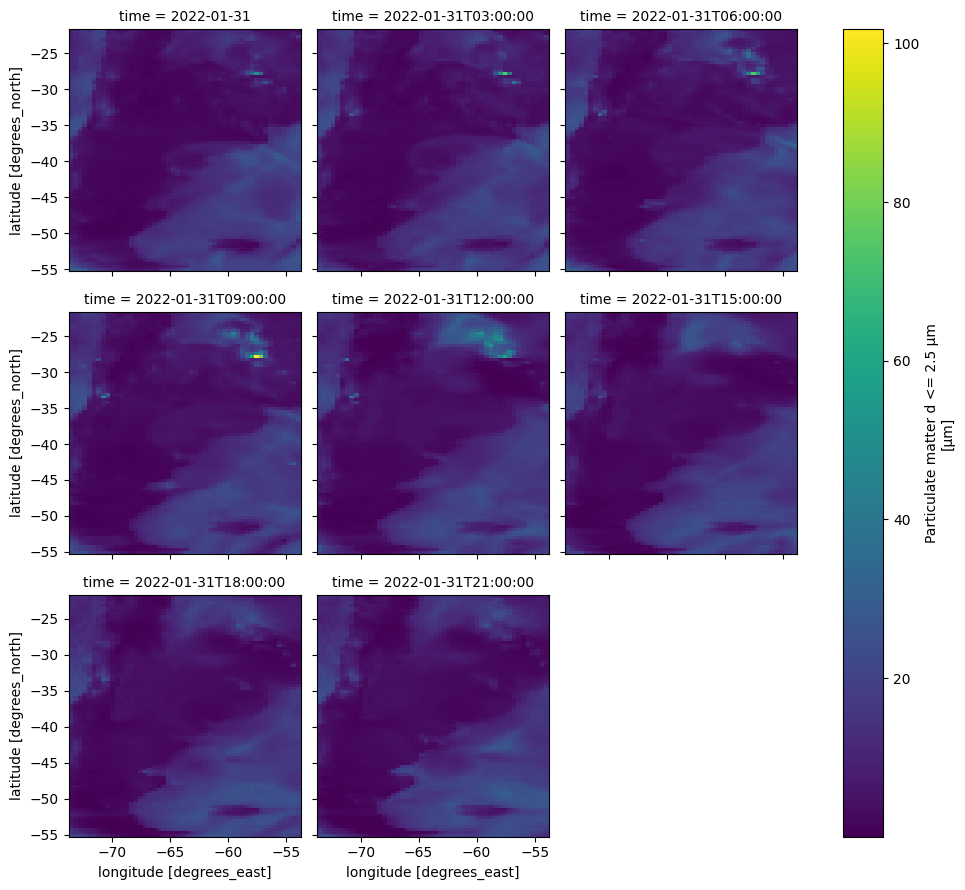

In [36]:
ds.sel(time='2022-01-31').pm2p5.plot(col='time', col_wrap=3)

Puede ser que todavía no les haya impresionado el uso de cubo de datos... Por eso, veamos las posibilidades de calculos estadísticos.

## Cálculo estadísticos (dimensión temporal)

El cubo de dato de particulado fino que estamos manipulando posee información de la concentración a cada tres horas. Pero, la Organización Mundial de la Salud establece un valor límite diário.
Así que, aunque sea interesante conocer la concentración de polución a cada tres horas, necesitamos conocer el valor medio diario, ara poder identificar qué días tuvimos valores médios diários mayor al recumendado por la OMS.

Gracias al cubo de datos, podemos hacer eso de manera simple. Lo que haremos es, antes de calcular el valor medio, agrupar los datos por cada día en la dimención "time".   
O sea: `ds.groupby("time.date")`.
Y en seguida usaremos el método `mean()`, que hará el calculo de la média de particulado fino por día:  
`ds.groupby("time.date").mean()`  

**Atención:** agruparemos por cada día, o sea a cada fecha. No a cada día.

Dicho proceso es conocido también como "remuestreo temporal":
<figure>
    <img src="https://openeo.org/assets/img/dc_resample_time.987e797c.png" width=100%
         alt="Ilustración del proceso de remuestreo temporal. [fuente: Open EO](https://openeo.org/documentation)">
    <figcaption>Ilustración del proceso de remuestreo temporal. <a href=https://openeo.org/documentation>fuente: Open EO.</a></figcaption>
</figure>




In [37]:
ds.groupby("time.date").mean()

<xarray.Dataset> Size: 12MB
Dimensions:    (date: 366, latitude: 84, longitude: 50)
Coordinates:
  * date       (date) object 3kB 2022-01-01 2022-01-02 ... 2022-12-31 2023-01-01
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Data variables:
    pm2p5      (date, latitude, longitude) float64 12MB 15.26 14.7 ... 21.36
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-19 16:53:09 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

Para facilitar, vamos guardar el resultado de la media diária en un objeto `media_diaria`, para poder usarlo en otras operaciones.

In [38]:
media_diaria = ds.groupby("time.date").mean()

Una vez hecho el calculo de la media diária, como podría acceder al valor diário para una fecha, por ejemplo 19/01/2022?

Sugerencia, tendremos qe usar el módulo `datetime`, cargado anteriormente...

In [39]:
fecha = datetime(2022, 1, 31).date()
media_diaria.sel(date=fecha).pm2p5

<xarray.DataArray 'pm2p5' (latitude: 84, longitude: 50)> Size: 34kB
array([[12.28009696, 13.52802935, 14.24665868, ...,  5.23801248,
         4.81969509,  4.62013343],
       [12.01608817, 12.84833607, 13.25979436, ...,  6.21799832,
         7.16090181,  5.40473541],
       [11.36870992, 11.67648981, 12.16209926, ...,  6.46836828,
         7.1420562 ,  8.90088067],
       ...,
       [21.77474368, 15.24013725, 12.80078798, ..., 19.53066981,
        20.90424795, 21.61514311],
       [22.2896703 , 16.27909631, 14.41528278, ..., 20.44374018,
        21.15445627, 21.21169584],
       [23.98633887, 23.10746627, 22.19371252, ..., 20.34316901,
        20.8509481 , 20.93028182]])
Coordinates:
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
    date       object 8B 2022-01-31
Attributes:
    units:          µm
    long_name:      Particulate matter d <= 2.5 µm
    standard_name:  mass_concentration_of_pm2p5_ambient_aerosol_particles_in_air

Y para hacer el plot de dicha fecha?

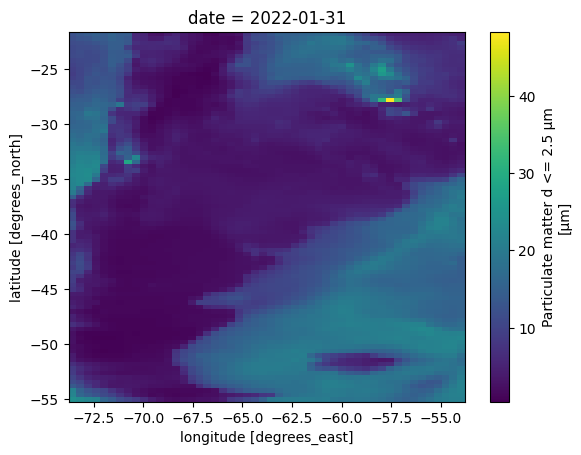

In [40]:
media_diaria.sel(date=fecha).pm2p5.plot()

Prueben hacer el plot de otras fechas...
Ejemplo: 18/01/2022

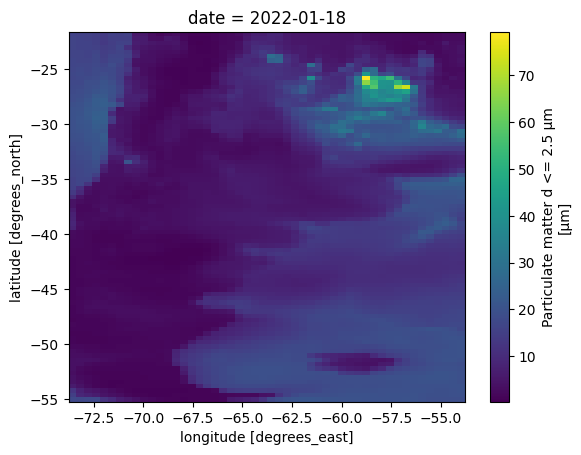

In [41]:
fecha = datetime(2022, 1, 18).date()
media_diaria.sel(date=fecha).pm2p5.plot()

## Añadiendo dato vectorial

Hasta ahora estuvimos trabajando con cubo de datos matriciales...  
Pero cómo podríamos hacer una determinada operación entre el cubo y un dato raster?

Antes de todo, cargamos el dato vectorial con los límites provinciales de la Argentina.

<Axes: >

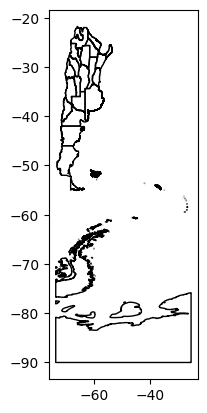

In [43]:
prov = gpd.read_file(
    "/content/drive/MyDrive/UNaM/FCF/TUSIGyT/Primer cuatrimestre/GAAT - Geomática_Analisis_Territorial/2024/Datos/provincia.shp"
    ) # no se olviden de cambiar la ruta al archivo...
prov.plot(facecolor="None")

### Visualización del cubo de datos + dato vectorial

Y el "mapa" (plot)?  
Cómo lo haríamos?

<Axes: title={'center': 'date = 2022-01-18'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

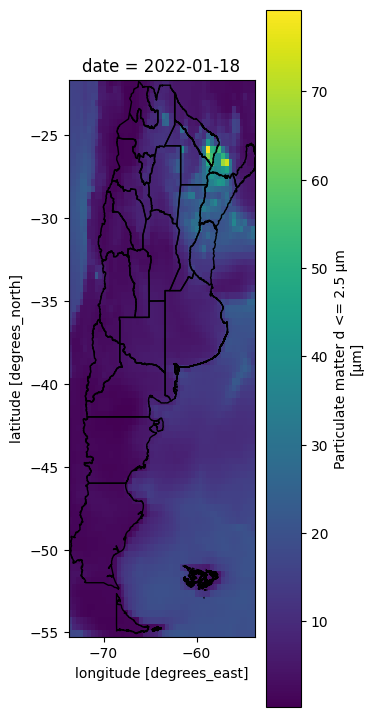

In [44]:
p = media_diaria.sel(date=fecha).pm2p5.plot(figsize=(3, 20))
prov.plot(facecolor="none", ax=p.axes)

La representación gráfica del `xarray` nos permite de una manera facilitada, definir umbrales (valores que quiebras) para agrupar valoes en algunos grupos.
Para eso basta usar en el `plot()` el parámetro `levels` el cual deberá recibir un listado de valores que definirán los grupos:
`ds.variable.plot(levels=[10, 25, 37.5])`

<Axes: title={'center': 'date = 2022-01-18'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

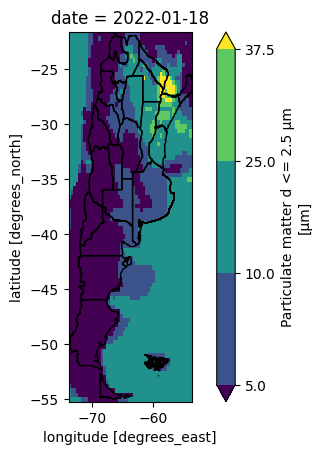

In [45]:
p = media_diaria.sel(date=fecha).pm2p5.plot(levels=[5, 10, 25, 37.5])
prov.plot(facecolor="none", ax=p.axes)

## Estadística zonal y cubo de datso vectoriales

Y cómo haremos para conocer el valor medio de particulado fino por provincia?  
Para eso, trajaremos con la estadística zonal.
Para eso vamos a ocupar la herramienta [`zonal_stats`](https://xvec.readthedocs.io/en/stable/zonal_stats.html) del módulo `xvec`, instalado e impotando al princípio del proyecto.

Por cuestiones didácticas (y para acelerar el proceso), iré transformar la media diária en media mensal.

In [46]:
media_mensual = ds.groupby("time.month").mean()
media_mensual

<xarray.Dataset> Size: 404kB
Dimensions:    (month: 12, latitude: 84, longitude: 50)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float32 336B -21.86 -22.26 -22.66 ... -54.66 -55.06
  * longitude  (longitude) float32 200B -73.57 -73.17 -72.77 ... -54.37 -53.97
Data variables:
    pm2p5      (month, latitude, longitude) float64 403kB 13.18 13.21 ... 19.17
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-19 16:53:09 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [47]:
estats_mensual = media_mensual.xvec.zonal_stats(
    prov.geometry.values,
    x_coords="longitude",
    y_coords="latitude"
)
estats_mensual

<xarray.Dataset> Size: 3kB
Dimensions:   (month: 12, geometry: 24)
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * geometry  (geometry) geometry 192B POLYGON ((-58.45535088799994 -34.52776...
Data variables:
    pm2p5     (geometry, month) float64 2kB nan nan nan ... 4.041 3.624 4.625
Indexes:
    geometry  GeometryIndex (crs=EPSG:4326)
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-19 16:53:09 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [48]:
estats_mensual = estats_mensual.xvec.to_geodataframe()
estats_mensual.head()

Output hidden; open in https://colab.research.google.com to view.

In [49]:
estats_mensual.loc[1]

,geometry,pm2p5
month,,
1,"POLYGON ((-58.45535 -34.52776, -58.45404 -34.5...",NaN
1,"POLYGON ((-70.39341 -36.15624, -70.39333 -36.1...",2.979925
1,"POLYGON ((-67.05547 -31.85605, -67.05 -31.8574...",4.970441
1,"POLYGON ((-61.04639 -27.998, -61.00805 -27.998...",9.472886
1,"POLYGON ((-68.52136 -27.81792, -68.52148 -27.8...",4.142948
1,"POLYGON ((-68.50537 -25.16851, -68.50386 -25.1...",3.262029
1,"POLYGON ((-65.35915 -26.05944, -65.35868 -26.0...",7.041544
1,"POLYGON ((-62.32434 -24.12318, -62.31959 -24.1...",10.280436
1,"POLYGON ((-62.31201 -22.48666, -62.31056 -22.4...",16.085200


<Axes: >

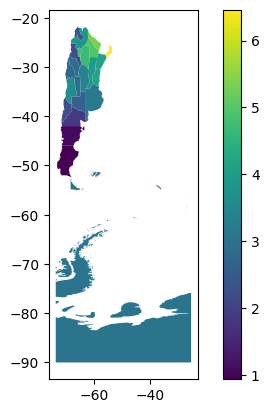

In [52]:
estats_mensual.loc[4].plot(column='pm2p5', legend=True)